

# Treasury Yield-Curve Factor Research and a Relative-Value Trading Framework


The goal of this notebook is not only to run the code, but to understand:

1. what a bond is,
2. what a yield curve is,
3. why Treasury yields tend to move together,
4. how principal component analysis (PCA) is used on the curve,
5. how the code turns those factors into a simple relative-value strategy,
6. what the limitations of the project are, and
7. how I could improve it.

## How to read this notebook

This notebook is written in layers.

- **Finance intuition first**: bonds, yields, the term structure, and why the curve matters.
- **Math second**: covariance matrices, eigenvalues, eigenvectors, PCA, projections, z-scores, and DV01-style risk scaling.
- **Code third**: loading the data, extracting factors, building butterfly trades, and backtesting both a stylized and a more realistic implementation.
- **Research framing last**: methodology, results, limitations, and what the notebook does and does not support credibly.

I started this project without any fixed-income background and learnt concepts when needed. Therefore, everything I learnt is also in notebook.


## 1) What is a bond?
A **bond** is a fixed-income investment product where individuals lend money to a government or company at a specified interest rate (also known coupon rate) for a predetermined period. The entity repays individuals with interest (also knowns as coupons on specific dates) in addition to the original face value of the bond at the end of maturity (end of the predetermined period).

Bonds are not always held to maturity. They can be traded on a secondary market, and their price can fluctuate based on interest rates, creditworthiness, and market demand, meaning you may not sell it for the original price. It's important to note that a bond’s price varies inversely with interest rates. When rates go up, bond prices fall to equalize the interest rate on the bond with prevailing rates, and vice versa.
<br><br>
The simplest cases are:

### Zero-coupon bond
A zero-coupon bond do not pay coupon payments and instead are issued at a discount to their par (face) value. The difference between the purchase price of a zero-coupon bond and its par value is the investor's return. U.S. Treasury bills are zero-coupon bonds.


If the face value is $F$ and the $n$-year rate of interest is $z_n$, then the price is

$$
P_n = \frac{F}{(1+z_n)^n}
$$




### Coupon bond
A coupon bond pays periodic coupons plus principal (face value) at maturity.

Note that money received in the future is worth **less** than money received today, because money today can be invested immediately. Hence, pricing a coupon bond involves first converting each future payment into its **present value**. This is done using a **discount rate**.

If a payment of $C$ is received at time $t$ from now and the discount rate is $r$, then its present value is

$$
\text{PV} = \frac{C}{(1+r)^t}.
$$

In real markets, the appropriate rate for a 1-year cash flow is usually not the same as the rate for a 10-year cash flow.

That is why we may use:

- $r_1$ for the cash flow at time 1
- $r_2$ for the cash flow at time 2
- ...
- $r_n$ for the cash flow at time $n$

If the coupon payment is $C$, the face value is $F$, and the relevant discount rates are $r_1,...,r_n$, then the price is

$$
P = \sum_{t=1}^{n} \frac{C}{(1+r_t)^t} + \frac{F}{(1+r_n)^n}.
$$

### Key intuition
- **Higher discount rates $\rightarrow$ lower bond prices**
- **Lower discount rates $\rightarrow$ higher bond prices**

That inverse price-yield relationship is one of the most important ideas in fixed income.

## 2) What is a yield?

A **yield** is a way of expressing the return associated with a bond. It depends on the bond’s cash flows and the bond’s market price.

Suppose a bond pays fixed cash flows. Those cash flows do not change just because investors become more eager to buy the bond. So if investors bid the **price up** (more demand for the bond means investors are willing to pay more for it), they are paying more today for the same future cash flows. That means the return they earn from buying it must be lower.
So:

$$
\text{higher price} \rightarrow \text{lower yield}
\qquad\text{and}\qquad
\text{lower price} \rightarrow \text{higher yield}.
$$
<br><br>
Some relevant yield concepts:
### Zero-coupon yield (spot rate)

A **zero-coupon bond** pays only one cash flow:  
it pays nothing before maturity, and then pays its face value at maturity.

If a zero-coupon bond matures at time $t$, its price is

$$
P = \frac{F}{(1+r_t)^t},
$$

where $r_t$ is the **zero-coupon yield** or **spot rate** for maturity $t$.

So the zero-coupon yield is the discount rate for **one pure cash flow at one specific maturity**.

This makes zero rates extremely useful, because they give us the correct discount rate for each maturity separately.

### Par yield

A **par bond** is a bond whose price is equal to its face value.

The **par yield** for a given maturity is the coupon rate that would make a newly issued bond of that maturity trade exactly at par.

Par yields are often quoted in market data because they are easy to interpret and closely related to the rates at which coupon bonds are issued.
<br><br>
So:

- **Zero yields** are discount rates for single cash flows at specific maturities
- **Par yields** are coupon rates that make hypothetical coupon bonds trade at par

## 3) What is the yield curve?

Bonds of different maturities usually have different yields. The **yield curve** is a graph with:

- **maturity** on the horizontal axis
- **yield** on the vertical axis

It tells us how borrowing/lending rates differ across maturities.

For U.S. Treasuries, a curve might look like:

- 1-year Treasury yield = 3.8%
- 2-year Treasury yield = 4.0%
- 5-year Treasury yield = 4.2%
- 10-year Treasury yield = 4.4%
- 30-year Treasury yield = 4.5%

all on the same date. Connect them and you get a yield curve.

Why do people care?

- It summarizes market expectations about growth, inflation, and monetary policy.
- It drives pricing and hedging in rates markets.
- Different parts of the curve often move together, which makes the curve a natural candidate for **factor models**.

A yield curve can be:

- **upward sloping**: long maturities have higher yields (Very loosely, it can reflect expected future rate increases, compensation for locking money up longer, inflation uncertainty)
- **flat**: similar yields across maturities (This suggests the market sees similar rates across horizons, or that the curve is in transition.)
- **inverted**: short maturities have higher yields than long maturities (This often gets attention because it can reflect expectations that short rates may fall later, often due to slowing growth or future easing.)

The notebook studies how this curve moves over time.

The classic empirical result is that most yield curve movement can be described by three shapes:

1. **Level**: the whole curve shifts up or down.
2. **Slope**: short and long rates move differently.
3. **Curvature**: the belly of the curve moves differently from the wings.

This notebook checks that idea directly with PCA.

## 4) What data are we using?

This notebook uses the Federal Reserve's **nominal Treasury yield-curve** dataset from the Board's Gurkaynak-Sack-Wright term-structure estimates.

The important columns for us are:

- `SVENPY01` to `SVENPY30`: **par yields** from 1 to 30 years
- `SVENY01` to `SVENY30`: **zero-coupon yields** from 1 to 30 years
- `BETA0` to `BETA3`, `TAU1`, `TAU2`: parameters from the Fed's fitted yield-curve model

We mostly work with the **daily history of par yields by maturity**, because they give us a clean maturity-by-date panel for studying yield-curve moves.

Later, when we build a more realistic trading layer, we also use the **zero-coupon yields** to construct approximate zero-bond prices and DV01s.


In [32]:
import numpy as np
import pandas as pd
import numpy.linalg as LA
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False
pd.set_option("display.max_columns", 120)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

## 5) Load the data from the Federal Reserve


In [33]:
fed_data = pd.read_csv('feds200628.csv', skiprows=9)
fed_data["Date"] = pd.to_datetime(fed_data["Date"])
fed_data = fed_data.sort_values("Date").reset_index(drop=True)

print(f"Loaded {len(fed_data):,} rows and {fed_data.shape[1]} columns")
display(fed_data.head())


Loaded 16,903 rows and 100 columns


,Date,BETA0,BETA1,BETA2,BETA3,SVEN1F01,SVEN1F04,SVEN1F09,SVENF01,SVENF02,SVENF03,SVENF04,SVENF05,SVENF06,SVENF07,SVENF08,SVENF09,SVENF10,SVENF11,SVENF12,SVENF13,SVENF14,SVENF15,SVENF16,SVENF17,SVENF18,SVENF19,SVENF20,SVENF21,SVENF22,SVENF23,SVENF24,SVENF25,SVENF26,SVENF27,SVENF28,SVENF29,SVENF30,SVENPY01,SVENPY02,SVENPY03,SVENPY04,SVENPY05,SVENPY06,SVENPY07,SVENPY08,SVENPY09,SVENPY10,SVENPY11,SVENPY12,SVENPY13,SVENPY14,SVENPY15,SVENPY16,SVENPY17,SVENPY18,SVENPY19,SVENPY20,SVENPY21,SVENPY22,SVENPY23,SVENPY24,SVENPY25,SVENPY26,SVENPY27,SVENPY28,SVENPY29,SVENPY30,SVENY01,SVENY02,SVENY03,SVENY04,SVENY05,SVENY06,SVENY07,SVENY08,SVENY09,SVENY10,SVENY11,SVENY12,SVENY13,SVENY14,SVENY15,SVENY16,SVENY17,SVENY18,SVENY19,SVENY20,SVENY21,SVENY22,SVENY23,SVENY24,SVENY25,SVENY26,SVENY27,SVENY28,SVENY29,SVENY30,TAU1,TAU2
0,1961-06-14,3.9176,-1.2780,-1.9494,0.0000,3.8067,3.9562,NaN,3.5492,3.8825,3.9149,3.9174,3.9176,3.9176,3.9176,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.0025,3.3973,3.5724,3.6627,3.7169,3.7530,3.7787,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.9825,3.3771,3.5530,3.6439,3.6987,3.7351,3.7612,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.3392,-999.9900
1,1961-06-15,3.9785,-1.2574,-2.2476,0.0000,3.8694,4.0183,NaN,3.5997,3.9460,3.9763,3.9784,3.9785,3.9785,3.9785,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.0141,3.4339,3.6175,3.7117,3.7683,3.8060,3.8328,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.9941,3.4137,3.5981,3.6930,3.7501,3.7882,3.8154,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.3258,-999.9900
2,1961-06-16,3.9844,-1.4295,-1.8850,0.0000,3.8634,4.0242,NaN,3.5957,3.9448,3.9811,3.9841,3.9843,3.9843,3.9844,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.0213,3.4346,3.6188,3.7140,3.7713,3.8094,3.8365,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.0012,3.4142,3.5994,3.6953,3.7531,3.7917,3.8192,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.3488,-999.9900
3,1961-06-19,4.0044,-0.7233,-3.3107,0.0000,3.9196,4.0447,NaN,3.6447,3.9842,4.0035,4.0043,4.0044,4.0044,4.0044,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.0150,3.4589,3.6446,3.7387,3.7951,3.8327,3.8595,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.9949,3.4386,3.6252,3.7199,3.7768,3.8147,3.8418,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.2821,-999.9900
4,1961-06-20,3.9858,-0.9004,-2.8448,0.0000,3.8732,4.0257,NaN,3.5845,3.9552,3.9840,3.9857,3.9858,3.9858,3.9858,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.0034,3.4303,3.6178,3.7137,3.7713,3.8096,3.8370,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.9833,3.4101,3.5986,3.6952,3.7533,3.7921,3.8198,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.3103,-999.9900


Par yields: `SVENPY01`, `SVENPY02`, ..., `SVENPY30`

Zero yields: `SVENY01`, `SVENY02`, ..., `SVENY30`

Curve parameters: `BETA0`, `BETA1`, `BETA2`, `BETA3`, `TAU1`, `TAU2`

The important practical point is:

- **par yields** are easy to interpret as market coupon-bond rates by maturity,
- **zero yields** are more fundamental for discounting and pricing,
- the **parameter columns** are useful when comparing PCA with the Fed's parametric curve model later.


## 7) Extract zero-coupon and par-yield curves

The raw column names are things like `SVENPY05` or `SVENY10`.

To make the analysis readable, I rename them to integer maturities:

- `5` means 5-year
- `10` means 10-year
- `30` means 30-year

In [34]:
zero_cols = [c for c in fed_data.columns if c.startswith("SVENY")]
par_cols = [c for c in fed_data.columns if c.startswith("SVENPY")]

zero_yields = (
    fed_data[["Date"] + zero_cols]
    .rename(columns={c: int(c[-2:]) for c in zero_cols})
    .set_index("Date")
)
par_yields = (
    fed_data[["Date"] + par_cols]
    .rename(columns={c: int(c[-2:]) for c in par_cols})
    .set_index("Date")
)

print("Zero-yield matrix shape:", zero_yields.shape)
print("Par-yield matrix shape:", par_yields.shape)
display(par_yields.iloc[:5])


Zero-yield matrix shape: (16903, 30)
Par-yield matrix shape: (16903, 30)


,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30
Date,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
1961-06-14,3.0025,3.3973,3.5724,3.6627,3.7169,3.7530,3.7787,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1961-06-15,3.0141,3.4339,3.6175,3.7117,3.7683,3.8060,3.8328,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1961-06-16,3.0213,3.4346,3.6188,3.7140,3.7713,3.8094,3.8365,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1961-06-19,3.0150,3.4589,3.6446,3.7387,3.7951,3.8327,3.8595,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1961-06-20,3.0034,3.4303,3.6178,3.7137,3.7713,3.8096,3.8370,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


A lot of the earlier data is missing. Since I will need a want a clean 1Y to 30Y panel, I'll remove the dates with the missing values and only use the date from when all maturities are available.

From this point onward, I'll use **dates as the index**. That makes the later rolling-PCA, factor-projection, and backtest sections much easier to read, because every object is indexed by actual dates rather than integer row numbers.


In [35]:
start_date = par_yields[30].dropna().index[0]
yields = par_yields.loc[start_date:].dropna()

print("Analysis start date:", start_date.date())
print("Yield panel shape after cleaning:", yields.shape)
display(yields.head())


Analysis start date: 1985-11-25
Yield panel shape after cleaning: (10069, 30)


,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30
Date,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
1985-11-25,8.0050,8.5122,8.8855,9.1627,9.3714,9.5312,9.6560,9.7556,9.8368,9.9044,9.9618,10.0113,10.0546,10.0927,10.1266,10.1568,10.1839,10.2082,10.2301,10.2497,10.2674,10.2832,10.2974,10.3101,10.3215,10.3317,10.3409,10.3490,10.3563,10.3628
1985-11-26,8.0025,8.5071,8.8805,9.1592,9.3698,9.5315,9.6578,9.7584,9.8401,9.9076,9.9645,10.0130,10.0550,10.0917,10.1240,10.1526,10.1780,10.2006,10.2208,10.2389,10.2551,10.2696,10.2825,10.2941,10.3044,10.3136,10.3219,10.3293,10.3358,10.3417
1985-11-27,7.9919,8.5012,8.8721,9.1451,9.3490,9.5042,9.6250,9.7212,9.7996,9.8650,9.9205,9.9684,10.0104,10.0474,10.0803,10.1097,10.1360,10.1596,10.1808,10.1998,10.2169,10.2322,10.2459,10.2582,10.2692,10.2790,10.2878,10.2957,10.3027,10.3089
1985-11-29,7.9385,8.4616,8.8352,9.1057,9.3054,9.4565,9.5738,9.6677,9.7448,9.8097,9.8655,9.9141,9.9570,9.9952,10.0293,10.0598,10.0873,10.1119,10.1340,10.1538,10.1716,10.1875,10.2017,10.2145,10.2258,10.2360,10.2450,10.2531,10.2603,10.2667
1985-12-02,7.9657,8.4935,8.8727,9.1499,9.3568,9.5153,9.6398,9.7401,9.8229,9.8926,9.9521,10.0037,10.0488,10.0885,10.1235,10.1545,10.1821,10.2065,10.2282,10.2475,10.2647,10.2799,10.2934,10.3054,10.3161,10.3256,10.3340,10.3415,10.3481,10.3540


## 9) Plot a few yield curves

A yield curve is a **snapshot across maturities on one date**.

This plot helps build intuition before doing any math.

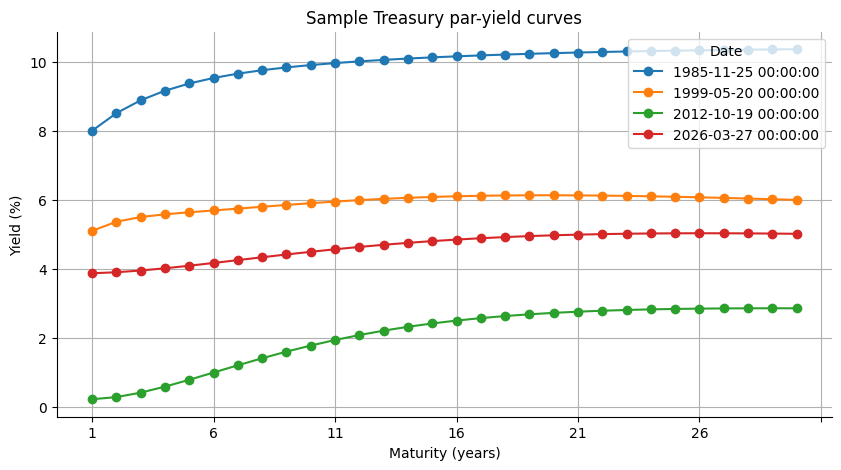

In [36]:
sample_dates = [
    yields.index[0],
    yields.index[len(yields)//3],
    yields.index[2*len(yields)//3],
    yields.index[-1],
]

ax = yields.loc[sample_dates].T.plot(marker="o")
ax.set_title("Sample Treasury par-yield curves")
ax.set_xlabel("Maturity (years)")
ax.set_ylabel("Yield (%)")
plt.show()

## 10) Why analyze **yield changes** instead of yield levels?

This is the point where the notebook shifts from **describing the curve** to **studying how the curve moves**.

Suppose:

- $y_t$ = the whole yield curve on date $t$
- $y_{t-1}$ = the whole yield curve on the previous date

Then the **daily yield-change vector** is

$$
\Delta y_t = y_t - y_{t-1}.
$$

So if the 5-year yield was 4.20\% yesterday and 4.25\% today, then the 5-year entry in $\Delta y_t$ is \+0.05\%, or **+5 basis points**.

### Why not just use yield levels?

Because yield **levels** and yield **changes** answer different questions.

- Yield **levels** tell us where rates are.
- Yield **changes** tell us how rates moved.

This project is about **co-movements**. We want to know things like:

- Did the whole curve move up together?
- Did short rates move more than long rates?
- Did the belly move differently from the wings?

Those are all questions about **changes**, not levels.

### Why are changes better for PCA here?

PCA works on variation and co-movement. In other words, it asks:

> "What are the main patterns in how these variables move together?"

That matches yield changes naturally.

Using changes keeps the focus on **movement**.


### Lead version

Define

$$
\Delta y_{t+1},
$$

as **the next day's move**.

This matters because the notebook estimates PCA loadings using information available through date $t$, and then applies those loadings to the move that occurs on date $t+1$.

That ordering is important for avoiding **look-ahead bias**.

### What is look-ahead bias?

Look-ahead bias means accidentally using information from the future when pretending to make a decision in the past.

A clean research design should be:

1. use data through date $t$ to estimate the factor directions,
2. apply those directions to the move on date $t+1$,
3. only then evaluate whether the factor model or signal worked.

That separation makes the backtest much more credible.


In [37]:
yield_changes = yields.diff(1)
next_day_yield_changes = yield_changes.shift(-1)

yield_changes.columns.name = "tenor"
next_day_yield_changes.columns.name = "tenor"

yield_changes.head()

tenor,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30
Date,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
1985-11-25,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1985-11-26,-0.0025,-0.0051,-0.0050,-0.0035,-0.0016,0.0003,0.0018,0.0028,0.0033,0.0032,0.0027,0.0017,0.0004,-0.0010,-0.0026,-0.0042,-0.0059,-0.0076,-0.0093,-0.0108,-0.0123,-0.0136,-0.0149,-0.0160,-0.0171,-0.0181,-0.0190,-0.0197,-0.0205,-0.0211
1985-11-27,-0.0106,-0.0059,-0.0084,-0.0141,-0.0208,-0.0273,-0.0328,-0.0372,-0.0405,-0.0426,-0.0440,-0.0446,-0.0446,-0.0443,-0.0437,-0.0429,-0.0420,-0.0410,-0.0400,-0.0391,-0.0382,-0.0374,-0.0366,-0.0359,-0.0352,-0.0346,-0.0341,-0.0336,-0.0331,-0.0328
1985-11-29,-0.0534,-0.0396,-0.0369,-0.0394,-0.0436,-0.0477,-0.0512,-0.0535,-0.0548,-0.0553,-0.0550,-0.0543,-0.0534,-0.0522,-0.0510,-0.0499,-0.0487,-0.0477,-0.0468,-0.0460,-0.0453,-0.0447,-0.0442,-0.0437,-0.0434,-0.0430,-0.0428,-0.0426,-0.0424,-0.0422
1985-12-02,0.0272,0.0319,0.0375,0.0442,0.0514,0.0588,0.0660,0.0724,0.0781,0.0829,0.0866,0.0896,0.0918,0.0933,0.0942,0.0947,0.0948,0.0946,0.0942,0.0937,0.0931,0.0924,0.0917,0.0909,0.0903,0.0896,0.0890,0.0884,0.0878,0.0873


## 11) Quick correlation check

Before running PCA, it is worth asking a simpler and more intuitive question:

> **Do different maturities usually move together?**

If the answer is yes, that is strong evidence that a low-dimensional factor model may work.

### What this table will show

The code below computes the correlation matrix of daily yield changes for a few selected maturities.

If most entries are large and positive, that means:

- 2Y, 5Y, 10Y, 30Y, etc. tend to move in the same direction on the same days,
- the yield curve is not behaving like 30 independent series,
- a few common forces may explain most of the action.

That is exactly the kind of structure PCA is designed to summarize.

### How to read one entry

If the correlation between 2Y and 10Y daily changes is, say, 0.90, that means those two maturities tend to move together very strongly from day to day.

Not that it does **not** mean they move by the same number of basis points every day, just that their movements are strongly aligned.


In [38]:
corr_table = (yield_changes[[2, 3, 5, 7, 10, 30]].dropna().corr() * 100).round(1)
corr_table

tenor,2,3,5,7,10,30
tenor,,,,,,
2,100.0000,98.5000,92.8000,87.3000,81.0000,67.8000
3,98.5000,100.0000,97.3000,92.8000,86.9000,74.2000
5,92.8000,97.3000,100.0000,98.6000,94.6000,83.5000
7,87.3000,92.8000,98.6000,100.0000,98.5000,88.9000
10,81.0000,86.9000,94.6000,98.5000,100.0000,92.5000
30,67.8000,74.2000,83.5000,88.9000,92.5000,100.0000


Seeing these very high positive correlations is the empirical reason PCA tends to work well on yield curves.

In plain English:

- if most maturities often move together,
- then there is probably a **common curve-wide force** behind those moves,
- and PCA can try to identify that force mathematically.


## 12) The main math: covariance matrices and PCA

Now we move from a simple correlation table to the full mathematical object that PCA uses.

### The object we feed into PCA

On each date $t$, we observe a full vector of daily yield changes across maturities:

$$
\Delta y_t \in \mathbb{R}^{30}.
$$

This can be thought of as one snapshot of the curve's daily movement:
- one number for the 1Y move,
- one number for the 2Y move,
- $\dots$
- one number for the 30Y move.

So each day gives us **one 30-dimensional movement vector**.

### Covariance matrix

A covariance matrix summarizes how every maturity co-moves with every other maturity.

Using a rolling window of length $w$, define

$$
\Sigma_t = \operatorname{Cov}(\Delta y_{t-w+1}, \dots, \Delta y_t).
$$

In this notebook we'll use the window of **504 trading days**, which is roughly **two years**.

So at each date $t$, we look back over the recent two-year history and ask:

- which maturities usually move together?
- which maturities tend to move in opposite directions?
- how large are those joint movements?

That entire picture is stored inside the matrix $\Sigma_t$.

### Why rolling instead of one full-sample covariance matrix?

Because the yield curve does not behave exactly the same in all market environments.

For example:

- crisis periods can look different from calm periods,
- Fed hiking cycles can differ from easing cycles,
- inflation regimes can alter how the front end and long end move.

A rolling window lets the factor structure adapt through time.

### What does PCA do?

PCA takes the covariance matrix and looks for its most important movement directions.

Mathematically, it solves the eigenvalue problem

$$
\Sigma_t v_k = \lambda_k v_k.
$$

Here:

- $v_k$ is the $k$-th eigenvector and is the loading vector for factor $k$ at date $t$. It tells us what a particular factor-driven move would look like across the curve.
- $\lambda_k$ is the corresponding eigenvalue and is the amount of variance explained by that factor. It tells us how important that movement pattern is.

Intuition:

- the covariance matrix tells us **how the curve tends to move**,
- PCA tries to find the **dominant movement shapes** hidden inside that covariance matrix.

### Why do people call these "factors"?

Because each eigenvector is a common pattern of movement shared by many maturities.

In fixed income, the first few factors often look like:

- **PC1 / level**: most maturities move in the same direction,
- **PC2 / slope**: short and long maturities move in opposite ways,
- **PC3 / curvature**: the belly moves differently from the wings.

### Sign is arbitrary

If $v_k$ is an eigenvector, then $-v_k$ is also an eigenvector.

So PCA does not care whether a factor is plotted upside down. For interpretation and plotting, we have to choose a consistent sign convention later.


In [39]:
ROLLING_WINDOW = 504  # roughly 2 years of trading days

rolling_cov = yield_changes.dropna().rolling(
    window=ROLLING_WINDOW,
    min_periods=ROLLING_WINDOW
).cov().dropna()

print("Rolling covariance shape:", rolling_cov.shape)
rolling_cov.head()

Rolling covariance shape: (286950, 30)


tenor                 1      2      3      4      5      6      7      8  \
Date       tenor                                                           
1987-12-02 1     0.0037 0.0039 0.0040 0.0041 0.0041 0.0041 0.0041 0.0041   
           2     0.0039 0.0046 0.0050 0.0052 0.0052 0.0052 0.0052 0.0051   
           3     0.0040 0.0050 0.0056 0.0059 0.0060 0.0060 0.0060 0.0060   
           4     0.0041 0.0052 0.0059 0.0063 0.0065 0.0066 0.0066 0.0066   
           5     0.0041 0.0052 0.0060 0.0065 0.0068 0.0069 0.0070 0.0070   

tenor                 9     10     11     12     13     14     15     16  \
Date       tenor                                                           
1987-12-02 1     0.0040 0.0040 0.0039 0.0039 0.0039 0.0038 0.0038 0.0038   
           2     0.0051 0.0050 0.0049 0.0049 0.0048 0.0048 0.0048 0.0047   
           3     0.0059 0.0058 0.0058 0.0057 0.0056 0.0056 0.0055 0.0055   
           4     0.0065 0.0064 0.0064 0.0063 0.0062 0.0062 0.0061 0.0061   
           5     0.0069 0.0069 0.0068 0.0067 0.0066 0.0066 0.0065 0.0064   

tenor                17     18     19     20     21     22     23     24  \
Date       tenor                                                           
1987-12-02 1     0.0037 0.0037 0.0037 0.0037 0.0037 0.0036 0.0036 0.0036   
           2     0.0047 0.0047 0.0047 0.0046 0.0046 0.0046 0.0046 0.0046   
           3     0.0055 0.0054 0.0054 0.0054 0.0054 0.0053 0.0053 0.0053   
           4     0.0060 0.0060 0.0059 0.0059 0.0059 0.0058 0.0058 0.0058   
           5     0.0064 0.0063 0.0063 0.0063 0.0062 0.0062 0.0062 0.0061   

tenor                25     26     27     28     29     30  
Date       tenor                                            
1987-12-02 1     0.0036 0.0036 0.0036 0.0036 0.0036 0.0036  
           2     0.0046 0.0046 0.0046 0.0046 0.0045 0.0045  
           3     0.0053 0.0053 0.0053 0.0053 0.0052 0.0052  
           4     0.0058 0.0058 0.0057 0.0057 0.0057 0.0057  
           5     0.0061 0.0061 0.0061 0.0061 0.0060 0.0060

## 13) Helper function: eigendecompose one covariance matrix

For each date, the rolling covariance step produces a 30 $\times$ 30 covariance matrix.

The helper function below does one job:

1. compute the eigenvalues and eigenvectors of that matrix,
2. sort the eigenvalues from largest to smallest,
3. return:
   - the eigenvectors as **factor loadings** across maturities,
   - the eigenvalues as **variance explained**.

### Why sort from largest to smallest?

Because PCA is usually interpreted in that order:

- factor 1 = most important direction,
- factor 2 = next most important,
- factor 3 = next most important, and so on.

If we did not sort them, "PC1" would not consistently mean "the strongest factor."


In [40]:
def eigendecompose_cov(cov_matrix: pd.DataFrame):
    # Return eigenvectors and eigenvalues sorted from largest to smallest eigenvalue.
    eigenvals, eigenvecs = LA.eigh(cov_matrix.to_numpy())
    order = np.argsort(eigenvals)[::-1]

    eigenvals = eigenvals[order]
    eigenvecs = eigenvecs[:, order]

    factor_index = pd.Index(range(1, len(eigenvals) + 1), name="factor")
    loading_df = pd.DataFrame(eigenvecs, index=cov_matrix.index, columns=factor_index)
    eigval_series = pd.Series(eigenvals, index=factor_index)

    return loading_df, eigval_series

## 14) Run PCA through time

This loop computes the PCA decomposition at every date where the rolling covariance matrix is available.

In [41]:
dates = rolling_cov.index.get_level_values(0).unique()

loading_frames = []
eigenvalue_rows = []

for d in dates:
    load_d, eigval_d = eigendecompose_cov(rolling_cov.loc[d])

    load_d = load_d.copy()
    load_d["Date"] = d
    load_d["tenor"] = load_d.index
    loading_frames.append(load_d.reset_index(drop=True).set_index(["Date", "tenor"]))

    eigval_d.name = d
    eigenvalue_rows.append(eigval_d)

loadings = pd.concat(loading_frames).sort_index()
eigenvalues = pd.DataFrame(eigenvalue_rows)
eigenvalues.index.name = "Date"

print("Loadings shape:", loadings.shape)
print("Eigenvalues shape:", eigenvalues.shape)
display(loadings.head())


Loadings shape: (286950, 30)
Eigenvalues shape: (9565, 30)


factor                1       2       3       4       5       6       7  \
Date       tenor                                                          
1987-12-02 1     0.1073 -0.3013 -0.4822 -0.6926 -0.3506  0.2351 -0.0756   
           2     0.1346 -0.3176 -0.4267  0.0062  0.3885 -0.5809  0.3745   
           3     0.1553 -0.3206 -0.2657  0.2878  0.3218  0.0642 -0.4249   
           4     0.1697 -0.3075 -0.0989  0.3346  0.0448  0.3626 -0.2156   
           5     0.1792 -0.2827  0.0355  0.2729 -0.1700  0.2823  0.1435   

factor                 8       9      10      11      12      13      14  \
Date       tenor                                                           
1987-12-02 1     -0.0371  0.0142  0.0027 -0.0035  0.0002  0.0005  0.0008   
           2      0.2265 -0.1213 -0.0306  0.0379 -0.0042 -0.0026 -0.0076   
           3     -0.4510  0.3713  0.1271 -0.1655  0.0321  0.0164  0.0305   
           4      0.1148 -0.3688 -0.2039  0.3141 -0.1108 -0.0670 -0.0683   
           5      0.3368 -0.1827  0.0162 -0.1552  0.1588  0.1238  0.1129   

factor                15      16      17      18      19      20      21  \
Date       tenor                                                           
1987-12-02 1      0.0006  0.0003 -0.0007 -0.0006 -0.0004 -0.0009 -0.0000   
           2     -0.0111 -0.0010  0.0034  0.0059  0.0060  0.0107  0.0025   
           3      0.0572  0.0058  0.0033 -0.0226 -0.0402 -0.0618 -0.0152   
           4     -0.1191 -0.0532 -0.0842  0.0182  0.1273  0.1964  0.0488   
           5      0.0931  0.1728  0.2737  0.0963 -0.1704 -0.3431 -0.1020   

factor                22      23      24      25      26      27      28  \
Date       tenor                                                           
1987-12-02 1     -0.0025  0.0000  0.0008  0.0001  0.0002  0.0007  0.0003   
           2      0.0316 -0.0027 -0.0102 -0.0008 -0.0002 -0.0094 -0.0014   
           3     -0.1603  0.0190  0.0340  0.0123 -0.0090  0.0525 -0.0084   
           4      0.3666 -0.0627 -0.0102 -0.0525  0.0362 -0.1331  0.0678   
           5     -0.3006  0.0913 -0.1585  0.0672  0.0169  0.1237 -0.1660   

factor                29      30  
Date       tenor                  
1987-12-02 1      0.0005 -0.0012  
           2     -0.0083  0.0124  
           3      0.0463 -0.0500  
           4     -0.1088  0.0766  
           5      0.0844  0.0057

## 15) Normalize factor signs for readability

Because eigenvector signs are arbitrary, the same factor can suddenly appear to flip upside down from one date to the next even when nothing economically meaningful changed.

To prevent that, we choose a consistent sign convention:

> make the **long end of the curve** positive on average.

This does **not** change the mathematics of the factor model. It only makes the plots readable through time.

Without this step, we get misleading visual jumps that are really just sign flips.


In [42]:
PCS = [1, 2, 3, 4, 5]

norm_loadings = loadings[PCS].copy()
norm_loadingsT = norm_loadings.stack().unstack(level="tenor")  # index: (Date, factor), columns: tenor

# Use the long end of the curve (20Y-30Y) to choose a consistent sign.
sign = np.sign(norm_loadingsT.loc[:, 20:30].sum(axis=1)).replace(0, 1)

norm_loadingsT = norm_loadingsT.mul(sign, axis=0)
norm_loadings = norm_loadingsT.stack().unstack(level="factor").sort_index()

norm_loadings.head()

factor                1       2       3       4       5
Date       tenor                                       
1987-12-02 1     0.1073 -0.3013  0.4822 -0.6926  0.3506
           2     0.1346 -0.3176  0.4267  0.0062 -0.3885
           3     0.1553 -0.3206  0.2657  0.2878 -0.3218
           4     0.1697 -0.3075  0.0989  0.3346 -0.0448
           5     0.1792 -0.2827 -0.0355  0.2729  0.1700

## 16) What do the first three PCA factors look like?

This is the first place where the PCA becomes economically interpretable.

We plot the latest loading shapes and ask whether they resemble the classic fixed-income factors.

### How to read a loading plot

A loading plot shows, for one factor, how strongly each maturity participates in that factor.

- If all maturities have roughly the same sign and similar magnitude, the factor looks like a **level shift**.
- If short maturities and long maturities have opposite signs, the factor looks like a **slope change**.
- If the middle maturities differ from both ends, the factor looks like **curvature**.

### Why this matters

If the first three factors really look like level, slope, and curvature, then the PCA is not just producing abstract linear algebra objects. It is recovering economically meaningful curve shapes.

That is one of the main empirical results in fixed-income PCA.


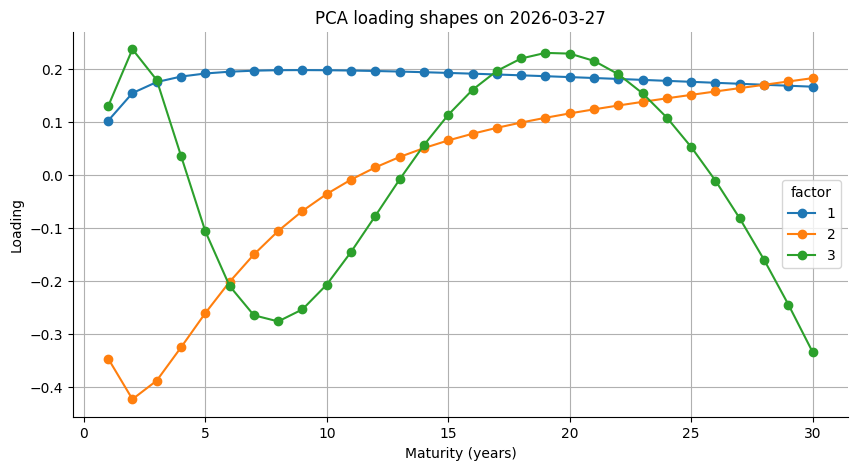

In [43]:
latest_date = norm_loadings.index.get_level_values("Date").max()

latest_shapes = norm_loadings.loc[latest_date, [1, 2, 3]]
ax = latest_shapes.plot(marker="o")
ax.set_title(f"PCA loading shapes on {latest_date.date()}")
ax.set_xlabel("Maturity (years)")
ax.set_ylabel("Loading")
plt.show()

A useful empirical checkpoint is whether the first few loading shapes admit a sensible fixed-income interpretation.

In many yield-curve PCA studies:

- **PC1** looks like a broad parallel shift of the curve, so it is interpreted as **level**,
- **PC2** tends to load short and long maturities with opposite signs, so it is interpreted as **slope**,
- **PC3** often resembles a curvature-type pattern, where the belly behaves differently from the wings.

These interpretations are only approximate. In real rolling estimates, especially for higher components like PC3, the shapes can be noisier and may not match the textbook sign pattern exactly on every date.

What matters is whether the factors are economically interpretable enough to guide trade design. If PC1 behaves like broad level risk and PC2 behaves like slope risk, then later we can talk about hedging **level** and **slope** exposure rather than just working with anonymous eigenvectors.

## 17) How much variance do the first factors explain?

The fraction of total variance explained by factor $k$ on date $t$ is

$$
\frac{\lambda_{k,t}}{\sum_j \lambda_{j,t}}.
$$

This number answers:

> "Out of all the daily yield-curve variation in the rolling window, how much is captured by factor $k$?"

### Why this matters

If the first three factors explain most of the variance, then the curve is effectively **low dimensional**.

That means:

- even though we observe 30 maturities,
- most of the movement can be summarized by only a few common drivers.

This is exactly what makes factor models useful in rates research and trading.

For Treasury curves, the first factor is usually dominant, the second is much smaller, and the third smaller again.

So a common pattern is:

- PC1 explains a very large share,
- PC2 explains a meaningful but much smaller share,
- PC3 explains a small but still useful share,
- the remaining factors explain only a thin tail of variation.


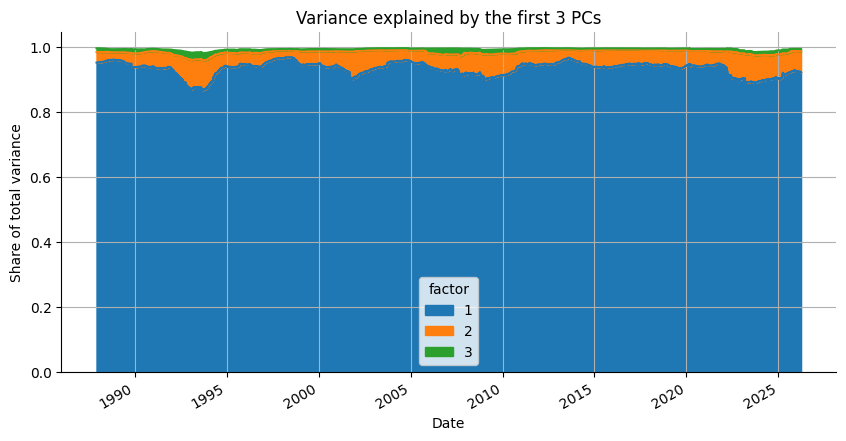

factor,1,2,3
mean,0.9346,0.0502,0.0088
min,0.8649,0.0210,0.0030
max,0.9691,0.0929,0.0236


In [44]:
var_explained = eigenvalues.div(eigenvalues.sum(axis=1), axis=0)

ax = var_explained[[1, 2, 3]].plot.area()
ax.set_title("Variance explained by the first 3 PCs")
ax.set_ylabel("Share of total variance")
plt.show()

var_explained[[1, 2, 3]].describe().loc[["mean", "min", "max"]]

## 18) See how the factor shapes evolve through time

Looking only at the latest date is useful, but it is not enough.

A stronger question is:

> **Do these shapes stay interpretable over time?**

The plots below sample the loading shapes at several points in the history.

What we want to see is not that they are perfectly identical, but that they remain recognizably close to:

- level,
- slope,
- curvature.

If they do, then the factor interpretation is reasonably stable rather than being a one-date accident.


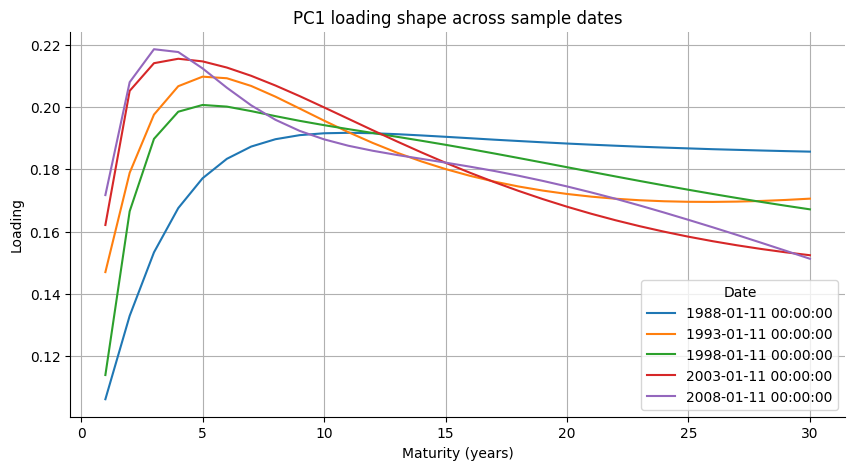

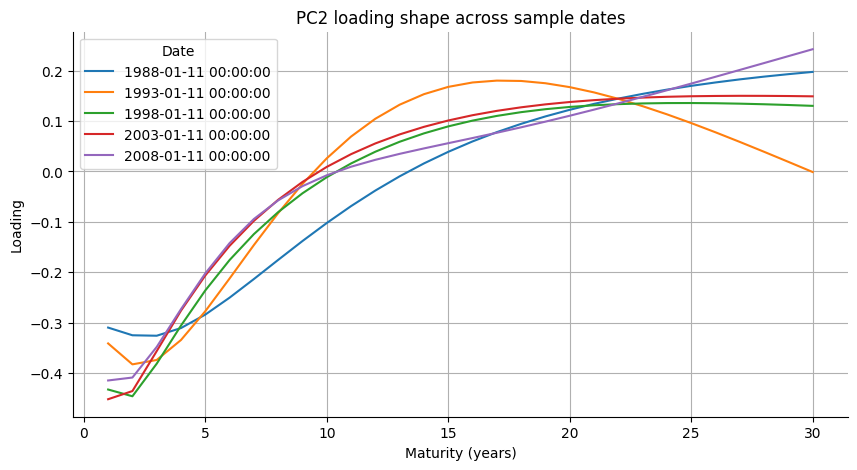

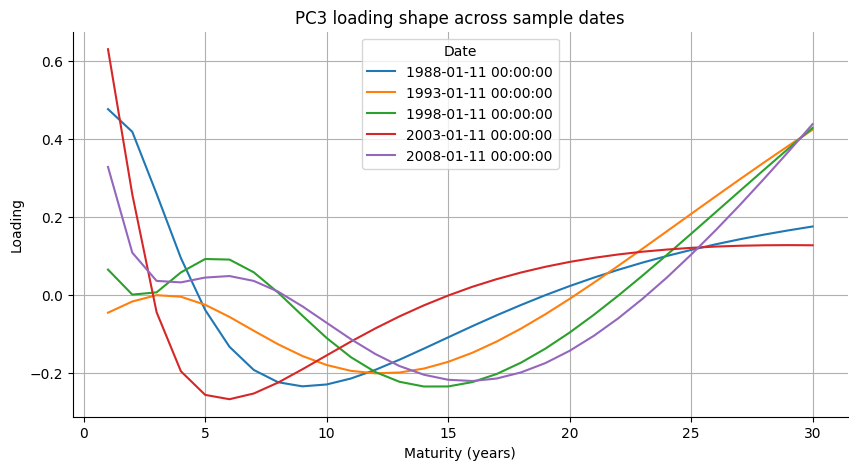

In [45]:
pc_start_date = norm_loadings.index.get_level_values("Date").min()

check_dates = pd.date_range(pc_start_date, periods=5, freq="5YS") + pd.offsets.Day(10)
check_dates = pd.Index(check_dates, name="Date")

def nearest_rows_by_date(df, target_dates):
    tmp = pd.DataFrame(index=target_dates)
    merged = pd.merge_asof(
        tmp.sort_index(),
        df.sort_index(),
        left_index=True,
        right_index=True,
        direction="nearest"
    )
    merged.index = target_dates
    return merged

for factor in [1, 2, 3]:
    sampled = nearest_rows_by_date(norm_loadingsT.xs(factor, level="factor"), check_dates)
    ax = sampled.T.plot()
    ax.set_title(f"PC{factor} loading shape across sample dates")
    ax.set_xlabel("Maturity (years)")
    ax.set_ylabel("Loading")
    plt.show()

## 19) From loadings to factor moves

So far, the PCA has given us **shapes**. Now we want to turn those shapes into **time-series factor realizations**.

Suppose $v_{k,t}$ is the loading vector for factor $k$ estimated using data through date $t$. Then the next day's move, $\Delta y_{t+1}$, can be projected onto that loading vector:

$$
f_{k,t+1} = v_{k,t}^{\top}\Delta y_{t+1}.
$$

### What does this projection mean?

It measures **how much of the next day's actual move lines up with factor $k$**.

So if the next day looked like a strong "level move," then the PC1 projection should be large.

If the next day mostly reflected a front-end versus long-end twist, then the PC2 projection should be large.

### Why is this step important?

Without it, PCA only gives us static pictures of curve shapes.

With it, we obtain a **time series** for each factor, which lets us:

- study factor dynamics,
- reconstruct fitted moves,
- compute residuals,
- and build trading signals.


In [46]:
max_date = next_day_yield_changes.loc[pc_start_date:].dropna().index[-1]
pcs_5 = [1, 2, 3, 4, 5]
pcs_3 = [1, 2, 3]

factor_lead_moves = pd.concat(
    [
        (
            next_day_yield_changes.loc[pc_start_date:max_date]
            * norm_loadingsT.loc[pc_start_date:max_date].xs(factor, level="factor")
        ).sum(axis=1)
        for factor in pcs_5
    ],
    axis=1,
    keys=pcs_5
)

display(factor_lead_moves.head())


,1,2,3,4,5
Date,,,,,
1987-12-02,-0.2844,0.0021,0.0032,-0.0086,0.0036
1987-12-03,0.0372,0.0350,-0.0025,-0.0015,-0.0001
1987-12-04,0.6220,0.0117,0.0292,0.0149,-0.0014
1987-12-07,0.0951,-0.0435,0.0093,-0.0471,0.0061
1987-12-08,-0.1039,-0.0002,0.0336,-0.0283,0.0076


## 20) Are the factor moves themselves highly correlated?

Inside the covariance matrix used for estimation, PCA factors are orthogonal by construction.

But once we project onto **future** moves, the resulting factor time series are not guaranteed to remain exactly uncorrelated.

So this check asks:

> after moving out of sample by one day, are the factor realizations still much cleaner than the raw yields?

Typically, they are not perfectly uncorrelated, but they should still be far less redundant than the original maturity-by-maturity yield changes.


In [47]:
(factor_lead_moves[pcs_3].corr() * 100).round(1)

,1,2,3
1,100.0000,3.9000,-0.8000
2,3.9000,100.0000,-5.4000
3,-0.8000,-5.4000,100.0000


## 21) Convert factor moves back into maturity-by-maturity components

This is the reconstruction step.

If factor $k$ moved by $f_{k,t+1}$, and its loading vector is $v_{k,t}$, then the part of the next day's curve move attributed to factor \(k\) is

$$
f_{k,t+1} v_{k,t}.
$$

That object has one entry for each maturity, so it is a **curve-shaped contribution**.

### Why do this?

Because it lets us break the actual next-day move into pieces:

- the part explained by factor 1,
- the part explained by factor 2,
- the part explained by factor 3,
- and whatever is left over.

This is the bridge from abstract factor time series back to an interpretable maturity-by-maturity decomposition.


In [48]:
tenors = norm_loadingsT.columns

pc_component_moves = pd.concat(
    [
        factor_lead_moves * norm_loadings.loc[pc_start_date:max_date].xs(tenor, level="tenor")
        for tenor in tenors
    ],
    axis=0,
    keys=tenors
)

pc_component_moves.head()

1       2       3       4       5
tenor Date                                              
1     1987-12-02 -0.0305 -0.0006  0.0016  0.0060  0.0013
      1987-12-03  0.0040 -0.0105 -0.0012  0.0010 -0.0000
      1987-12-04  0.0667 -0.0035  0.0141 -0.0103 -0.0005
      1987-12-07  0.0102  0.0131  0.0045  0.0326  0.0021
      1987-12-08 -0.0112  0.0001  0.0162  0.0196  0.0026

## 22) Residuals: what PCA does **not** explain

Let the actual next-day move be $\Delta y_{t+1}$, and let the fitted move using the first $K$ factors be

$$
\widehat{\Delta y}_{t+1}^{(K)} = \sum_{k=1}^{K} f_{k,t+1} v_{k,t}.
$$

Then the residual is

$$
r_{t+1}^{(K)} = \Delta y_{t+1} - \widehat{\Delta y}_{t+1}^{(K)}.
$$

### What is the residual telling us?

It is the part of the move that the first $K$ common factors did **not** explain.

### Why do residuals matter for trading?

If most of the curve is explained by broad level, slope, and curvature moves, then a relative-value strategy often wants to focus on the leftover part:

- something unusually rich,
- something unusually cheap,
- or a temporary distortion not explained by the main common factors.

That is the intuition behind looking at flies and mean reversion later on.


In [49]:
x0 = next_day_yield_changes.loc[pc_start_date:max_date].stack()

pc_residuals = (
    pc_component_moves
    .swaplevel(i=0, j=1)
    .sort_index()
    .cumsum(axis=1)
    .apply(lambda col: x0 - col)
)

resid = pc_residuals[3].unstack(level="tenor")
resid_zscore = (
    (resid - resid.ewm(halflife=10).mean())
    / resid.ewm(halflife=10).std()
)

resid.head()

tenor,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30
Date,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
1987-12-02,0.0078,-0.0028,-0.0033,-0.0023,-0.0012,-0.0004,0.0001,0.0004,0.0006,0.0007,0.0007,0.0007,0.0007,0.0006,0.0006,0.0005,0.0004,0.0004,0.0003,0.0002,0.0001,0.0000,-0.0001,-0.0002,-0.0003,-0.0004,-0.0005,-0.0006,-0.0007,-0.0008
1987-12-03,0.0011,-0.0002,-0.0004,-0.0004,-0.0003,-0.0002,-0.0001,-0.0001,0.0000,0.0001,0.0001,0.0002,0.0002,0.0002,0.0002,0.0002,0.0002,0.0002,0.0002,0.0002,0.0001,0.0001,0.0000,-0.0000,-0.0001,-0.0001,-0.0002,-0.0003,-0.0003,-0.0004
1987-12-04,-0.0115,0.0021,0.0050,0.0042,0.0029,0.0017,0.0008,0.0000,-0.0006,-0.0010,-0.0014,-0.0016,-0.0018,-0.0018,-0.0018,-0.0018,-0.0016,-0.0014,-0.0012,-0.0010,-0.0007,-0.0003,-0.0000,0.0004,0.0007,0.0011,0.0015,0.0019,0.0022,0.0026
1987-12-07,0.0362,-0.0061,-0.0151,-0.0140,-0.0102,-0.0061,-0.0024,0.0006,0.0028,0.0044,0.0054,0.0059,0.0060,0.0059,0.0055,0.0049,0.0042,0.0034,0.0026,0.0017,0.0009,0.0000,-0.0008,-0.0017,-0.0025,-0.0032,-0.0040,-0.0047,-0.0054,-0.0060
1987-12-08,0.0231,-0.0055,-0.0101,-0.0085,-0.0055,-0.0027,-0.0005,0.0011,0.0022,0.0028,0.0031,0.0032,0.0030,0.0028,0.0025,0.0022,0.0018,0.0014,0.0010,0.0006,0.0002,-0.0002,-0.0005,-0.0009,-0.0012,-0.0015,-0.0018,-0.0021,-0.0024,-0.0027


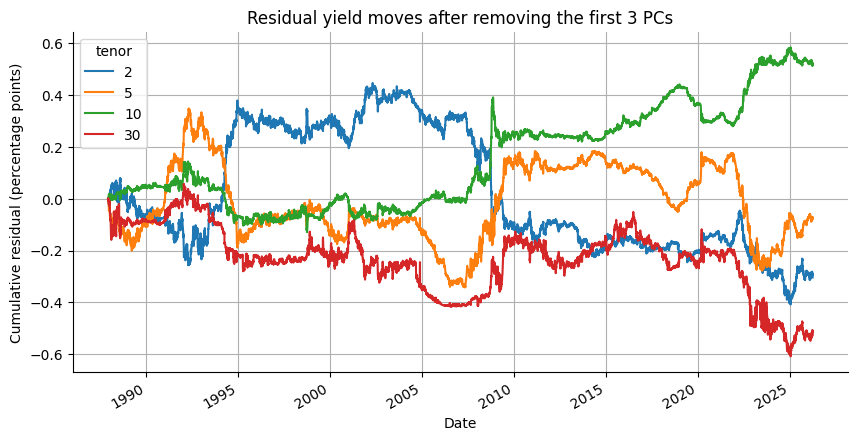

In [50]:
ax = resid.cumsum()[[2, 5, 10, 30]].plot()
ax.set_title("Residual yield moves after removing the first 3 PCs")
ax.set_ylabel("Cumulative residual (percentage points)")
plt.show()

## 23) Out-of-sample variance explained

One subtle but important question is:

> If I estimate PCA loadings earlier, how well do they still explain future curve behavior?

That is an **out-of-sample stability** question.


In [51]:

RUN_OOS_ANALYSIS = True

df_loadings = norm_loadings.loc[pc_start_date:]

def out_of_sample_variance_explained(loadings_df, eigenvalues_df, shift_size, factors=(1, 2, 3)):
    # Measure how much of today's variance is explained by factor directions
    # estimated `shift_size` days earlier.
    factors = list(factors)

    shifted = loadings_df[factors].unstack().shift(shift_size).stack().dropna()
    current = loadings_df.loc[shifted.index, factors]

    results = []
    for d in current.index.get_level_values("Date").unique():
        V_now = current.xs(d, level="Date").to_numpy()      # tenor x k
        V_old = shifted.xs(d, level="Date").to_numpy()      # tenor x k

        overlap = V_old.T @ V_now                           # k x k
        Lambda_now = np.diag(eigenvalues_df.loc[d, factors].to_numpy())

        explained_by_old_basis = np.diag(overlap @ Lambda_now @ overlap.T)
        explained_share = explained_by_old_basis / eigenvalues_df.loc[d].sum()

        results.append(pd.Series(explained_share, index=factors, name=d))

    return pd.DataFrame(results)

if RUN_OOS_ANALYSIS:
    shift_sizes = [1, 30, 60, 180, 252, 504]
    oos_results = {shift: out_of_sample_variance_explained(df_loadings, eigenvalues, shift) for shift in shift_sizes}
else:
    oos_results = None
    print("Skipping optional out-of-sample analysis. Set RUN_OOS_ANALYSIS = True to run it.")


/tmp/ipykernel_1263/231412410.py:10: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  shifted = loadings_df[factors].unstack().shift(shift_size).stack().dropna()
/tmp/ipykernel_1263/231412410.py:10: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  shifted = loadings_df[factors].unstack().shift(shift_size).stack().dropna()
/tmp/ipykernel_1263/231412410.py:10: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implem

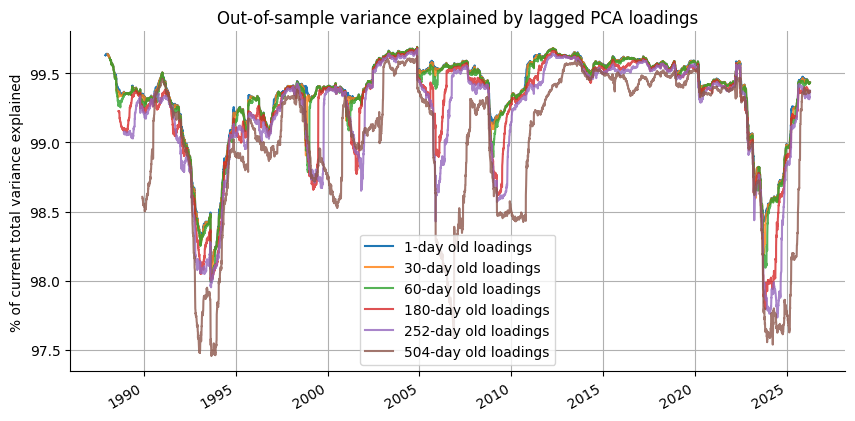

In [52]:

if oos_results is not None:
    ax = (oos_results[1] * 100).sum(axis=1).plot(label="1-day old loadings")
    for shift in [30, 60, 180, 252, 504]:
        (oos_results[shift] * 100).sum(axis=1).plot(ax=ax, alpha=0.8, label=f"{shift}-day old loadings")

    ax.set_title("Out-of-sample variance explained by lagged PCA loadings")
    ax.set_ylabel("% of current total variance explained")
    ax.legend()
    plt.show()
else:
    print("No out-of-sample plot because RUN_OOS_ANALYSIS is False.")


## 24) Strategy idea: a factor-neutral butterfly trade

Now we move from **describing the data** to **using the factor structure for a trading idea**.

A **butterfly** (or **fly**) combines three maturities. In this notebook we use:

- 5Y
- 7Y
- 10Y

### Why these three?

Because the 7Y maturity sits in the belly of the curve, while 5Y and 10Y act like the wings.

That makes the basket naturally suited to a **curvature-style** trade.

### What does "factor-neutral" mean here?

We choose weights so that the basket has approximately zero exposure to the first two PCA factors.

If $w$ is the basket weight vector and $V$ contains the PC1 and PC2 loading vectors for the selected maturities, then we want

$$
V^\top w = 0.
$$

That means the basket is designed to be roughly neutral to:

- the overall level move,
- the slope move.

So the remaining behavior is more focused on **curvature** or on smaller relative-value dislocations.

### Intuition

This is an attempt to say:

> "I do not want my trade to make money just because the whole curve rallied or because the curve steepened. I want a trade that is more specific than that."


In [53]:

SELECTED_TENORS = [5, 7, 10]

def pc_neutral_weights(loadings_df, tenors, factors=(1, 2), anchor_weight=1.0):
    # Faster vectorized version for a 3-tenor basket neutralized to 2 factors.
    if len(tenors) != 3 or len(factors) != 2:
        raise ValueError("This helper expects exactly 3 tenors and 2 factors.")

    sub = loadings_df.loc[(slice(None), tenors), list(factors)].copy()
    panel = sub.unstack(level="tenor")  # rows: Date, cols: (factor, tenor)

    A = np.stack(
        [panel.xs(tenor, axis=1, level="tenor").to_numpy() for tenor in tenors],
        axis=1
    )  # shape: (T, 3 tenors, 2 factors)

    W = np.transpose(A[:, 1:, :], (0, 2, 1))   # shape: (T, 2 factors, 2 unknown weights)
    b = (-anchor_weight * A[:, 0, :])[..., None]  # shape: (T, 2 factors, 1)

    sol = np.linalg.solve(W, b).squeeze(-1)     # shape: (T, 2)
    weights_arr = np.column_stack([np.full(len(panel), anchor_weight), sol])

    # normalize so the middle tenor has weight 1
    weights_arr = weights_arr / weights_arr[:, [1]]

    weights = pd.DataFrame(weights_arr, index=panel.index, columns=tenors)
    weights.index.name = "Date"
    return weights

weights = pc_neutral_weights(df_loadings, SELECTED_TENORS, factors=(1, 2))
weights.head()


,5,7,10
Date,,,
1987-12-02,-0.6041,1.0000,-0.4194
1987-12-03,-0.6040,1.0000,-0.4195
1987-12-04,-0.6041,1.0000,-0.4194
1987-12-07,-0.6042,1.0000,-0.4192
1987-12-08,-0.6044,1.0000,-0.4190


The resulting weights are not arbitrary. They are the weights that make the 5Y-7Y-10Y basket approximately insensitive to the first two PCA factors.

In practice, a typical pattern is:

- one sign on the 7Y belly,
- opposite signs on the 5Y and 10Y wings.

That is exactly what you would expect from a butterfly structure.

The code below first shows the **stylized yield-space basket**, which is helpful for intuition.

Later, we will build a **more realistic implementation layer** using zero-coupon prices, DV01-style risk scaling, volatility targeting, and simple transaction-cost assumptions.


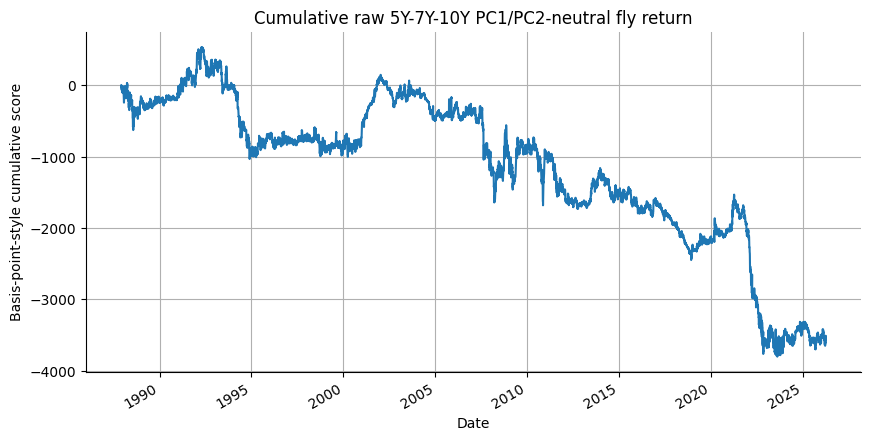

In [54]:
common_dates = weights.index.intersection(next_day_yield_changes.index)

pc_neutral_return = weights.loc[common_dates] * next_day_yield_changes.loc[common_dates, weights.columns]
pc_neutral_return_agg = pc_neutral_return.sum(axis=1)

ax = (pc_neutral_return_agg.cumsum() * 1e4).plot()
ax.set_title("Cumulative raw 5Y-7Y-10Y PC1/PC2-neutral fly return")
ax.set_ylabel("Basis-point-style cumulative score")
plt.show()

## 25) Turn the fly into a mean-reversion signal

The idea is:

> if the factor-neutral fly becomes unusually stretched, it may mean-revert.

To measure "unusually stretched," we standardize the fly's cumulative history using an **EWMA z-score**.

A z-score is

$$
z_t = \frac{x_t - \mu_t}{\sigma_t}.
$$

Here:

- $x_t$ is the lagged cumulative fly series,
- $\mu_t$ is an exponentially weighted moving average,
- $\sigma_t$ is an exponentially weighted moving standard deviation.

### Why cumulative first?

Daily fly returns are noisy. The cumulative series gives a smoother view of whether the fly has wandered unusually far from its recent history.

### Why EWMA?

EWMA reacts faster to new information than a simple rolling average.

That matters in markets because:

- very old observations should usually matter less,
- but we still want some memory of recent history.

### Why lag the state variable?

The state used for the signal is shifted by one day. That means today's trading decision depends only on information that would have been available before today's move was realized.

That is essential for a credible backtest.


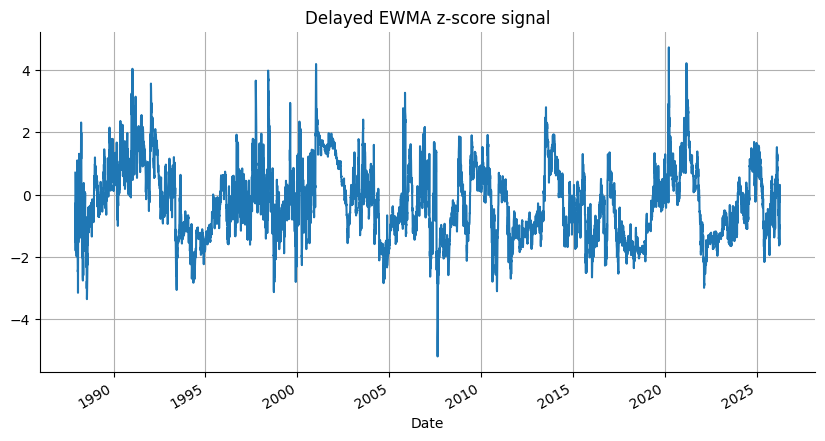

In [55]:
pc_neutral_return_agg_lag = pc_neutral_return_agg.shift(1).cumsum()

signal = (
    (pc_neutral_return_agg_lag - pc_neutral_return_agg_lag.ewm(halflife=100).mean())
    / pc_neutral_return_agg_lag.ewm(halflife=60).std()
)

signal_contemp = (
    (pc_neutral_return_agg.cumsum() - pc_neutral_return_agg.cumsum().ewm(halflife=100).mean())
    / pc_neutral_return_agg.cumsum().ewm(halflife=60).std()
)

ax = signal.plot()
ax.set_title("Delayed EWMA z-score signal")
plt.show()

## 26) The trading rule

A simple mean-reversion rule is:

- if the fly looks **rich** relative to its recent history, short it,
- if the fly looks **cheap** relative to its recent history, buy it.

In the code, that becomes a **negative exposure** to the z-score.

### What this cell is doing

1. estimate recent volatility,
2. convert the lagged fly dislocation into a signal,
3. trade against that signal on the next day's fly move.

### Very important backtesting point

The signal must be **delayed**.

Using today's full move to build today's signal and then trade today's return would be a form of look-ahead bias.

That is why the notebook compares:

- a **delayed** version, which is the research-credible version,
- and a **contemporaneous** version, which is intentionally shown as a warning example.


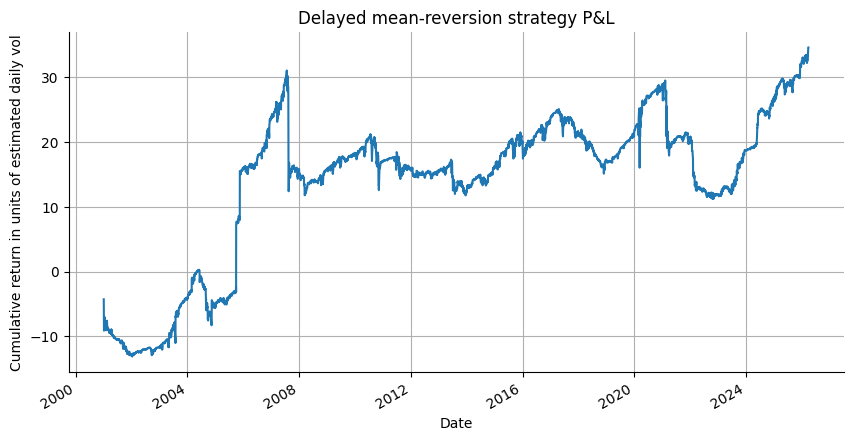

Strategy Sharpe from 2001 onward: 0.230


In [56]:
vol_est = pc_neutral_return_agg_lag.ewm(halflife=60).std()

strategy_return = -signal * pc_neutral_return_agg / vol_est

ax = strategy_return.loc["2001-01-01":].cumsum().plot()
ax.set_title("Delayed mean-reversion strategy P&L")
ax.set_ylabel("Cumulative return in units of estimated daily vol")
plt.show()

sharpe = strategy_return.loc["2001-01-01":].mean() / strategy_return.loc["2001-01-01":].std() * np.sqrt(252)
print(f"Strategy Sharpe from 2001 onward: {sharpe:.3f}")

## 27) What happens if we cheat?

The plot below uses a contemporaneous signal. That is not a fair backtest, but it is useful pedagogically because it shows how easy it is to accidentally overstate performance.

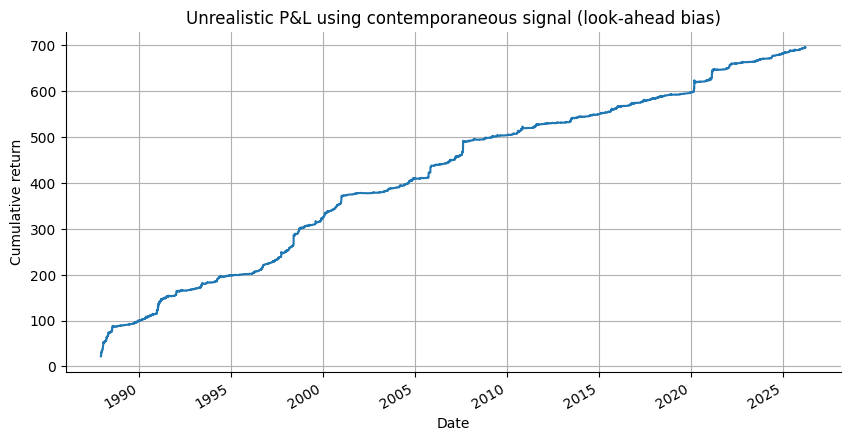

In [57]:
ax = (signal_contemp * pc_neutral_return_agg / vol_est).cumsum().plot()
ax.set_title("Unrealistic P&L using contemporaneous signal (look-ahead bias)")
ax.set_ylabel("Cumulative return")
plt.show()

## 28) A more realistic implementation layer

The earlier fly backtest is useful for intuition, but it still lives mostly in **yield space**.

A more realistic fixed-income implementation should move closer to **price / risk space**. The code below adds four improvements:

1. it uses **zero-coupon yields** to construct approximate zero-bond prices,
2. it uses **DV01-style risk scaling** when forming the 5Y-7Y-10Y basket,
3. it applies **signal delay, thresholding, and volatility targeting**,
4. it subtracts a simple **transaction-cost estimate** based on turnover.

This is still an approximation, because we are working with constant-maturity curve data rather than actual tradeable CUSIPs or futures. But it is much closer to a realistic research implementation than the earlier yield-only toy backtest.


In [58]:
SELECTED_TENORS = [5, 7, 10]
SIGNAL_START = "2001-01-01"

HALF_SPREAD_BPS = 0.25   # simple transaction-cost assumption per leg turnover
ENTRY_Z = 2.5            # only trade when the signal is meaningfully stretched
SIGNAL_CAP = 3.0         # cap very large z-scores
TARGET_DAILY_VOL = 0.01  # 1% daily vol target in strategy units

def zero_coupon_price(yield_pct, maturity):
    y = yield_pct / 100.0
    return 100.0 / (1.0 + y) ** maturity

def zero_coupon_dv01(yield_pct, maturity):
    y = yield_pct / 100.0
    price = zero_coupon_price(yield_pct, maturity)
    modified_duration = maturity / (1.0 + y)
    return price * modified_duration * 1e-4

def pc_neutral_risk_weights(loadings_df, zero_yield_df, tenors, factors=(1, 2), anchor_notional=1.0):
    rows = []
    common_dates = (
        loadings_df.index.get_level_values("Date").unique()
        .intersection(zero_yield_df.index)
    )

    for d in common_dates:
        load = loadings_df.loc[(d, tenors), list(factors)].to_numpy()  # tenor x factor
        y = zero_yield_df.loc[d, tenors].to_numpy()
        dv01 = np.array([zero_coupon_dv01(y_i, tenor) for y_i, tenor in zip(y, tenors)])

        # Convert factor exposures from pure yield-space into first-order dollar-risk space.
        risk_load = load * dv01[:, None]

        # Anchor the belly notional at +1 and solve for the two wing notionals.
        A = risk_load[[0, 2], :].T
        b = -anchor_notional * risk_load[1, :]

        wing_solution = np.linalg.solve(A, b)
        notionals = np.array([wing_solution[0], anchor_notional, wing_solution[1]])

        rows.append(pd.Series(notionals, index=tenors, name=d))

    weights = pd.DataFrame(rows)
    weights.index.name = "Date"
    return weights

risk_weights = pc_neutral_risk_weights(norm_loadings, zero_yields, SELECTED_TENORS, factors=(1, 2))
display(risk_weights.head())


,5,7,10
Date,,,
1987-12-02,-0.7014,1.0000,-0.3894
1987-12-03,-0.7021,1.0000,-0.3889
1987-12-04,-0.7021,1.0000,-0.3890
1987-12-07,-0.7008,1.0000,-0.3900
1987-12-08,-0.7005,1.0000,-0.3902


### What the more realistic basket weights mean

These are no longer just abstract yield weights.

They are **notional weights** for a 5Y-7Y-10Y basket chosen so that, to first order:

- exposure to **PC1** is close to zero,
- exposure to **PC2** is close to zero,
- the trade is expressed in a rough **dollar-risk (DV01-style)** language rather than raw yield units.

That makes the later P\&L interpretation more meaningful.


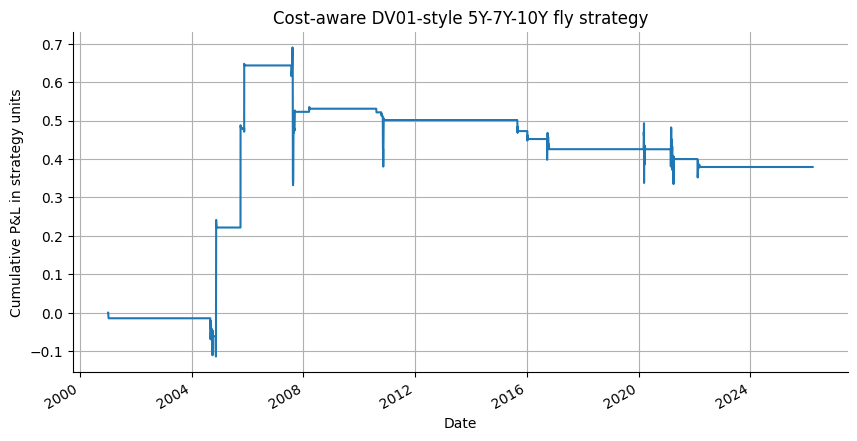

,Value
Annualized mean,0.0158
Annualized vol,0.1302
Sharpe,0.1216
Hit rate,0.0096
Max drawdown,-0.3584
Average daily turnover,0.0414


In [59]:
zero_prices = pd.DataFrame(
    {
        tenor: zero_coupon_price(zero_yields[tenor], tenor)
        for tenor in SELECTED_TENORS
    }
)

next_day_price_change = zero_prices.shift(-1) - zero_prices

common_dates = (
    risk_weights.index
    .intersection(next_day_price_change.dropna().index)
)

risk_fly_pnl = (
    risk_weights.loc[common_dates] * next_day_price_change.loc[common_dates, SELECTED_TENORS]
).sum(axis=1)

risk_fly_state = risk_fly_pnl.shift(1).cumsum()

risk_signal = (
    (risk_fly_state - risk_fly_state.ewm(halflife=100).mean())
    / risk_fly_state.ewm(halflife=60).std()
)

risk_signal_position = (
    (-risk_signal)
    .clip(-SIGNAL_CAP, SIGNAL_CAP)
    .where(risk_signal.abs() >= ENTRY_Z, 0.0)
)

risk_realized_vol = risk_fly_pnl.shift(1).ewm(halflife=40).std()
risk_position_scale = (TARGET_DAILY_VOL / risk_realized_vol).clip(upper=10)
risk_position_scale = risk_position_scale.replace([np.inf, -np.inf], np.nan).fillna(0.0)

risk_position = risk_signal_position * risk_position_scale

leg_position = risk_weights.loc[common_dates].mul(risk_position, axis=0)
leg_turnover = leg_position.diff().abs().fillna(leg_position.abs())

transaction_cost = (
    leg_turnover
    * zero_prices.loc[common_dates, SELECTED_TENORS]
    * (HALF_SPREAD_BPS * 1e-4)
).sum(axis=1)

realistic_strategy_pnl = risk_position * risk_fly_pnl - transaction_cost

ax = realistic_strategy_pnl.loc[SIGNAL_START:].cumsum().plot()
ax.set_title("Cost-aware DV01-style 5Y-7Y-10Y fly strategy")
ax.set_ylabel("Cumulative P&L in strategy units")
plt.show()

def summarize_strategy_returns(ret, turnover=None):
    ret = ret.dropna()
    summary = {
        "Annualized mean": ret.mean() * 252,
        "Annualized vol": ret.std() * np.sqrt(252),
        "Sharpe": ret.mean() / ret.std() * np.sqrt(252),
        "Hit rate": (ret > 0).mean(),
        "Max drawdown": (ret.cumsum() - ret.cumsum().cummax()).min(),
    }
    if turnover is not None:
        summary["Average daily turnover"] = turnover.loc[ret.index].mean()
    return pd.Series(summary)

realistic_summary = summarize_strategy_returns(
    realistic_strategy_pnl.loc[SIGNAL_START:],
    turnover=leg_turnover.sum(axis=1)
)

display(realistic_summary.to_frame("Value"))


## 29) Methodology in report form

### Objective
The objective of this project is to study the cross-maturity dynamics of the U.S. Treasury yield curve and determine whether a low-dimensional factor model can explain most day-to-day curve movement.

### Data
The project uses daily Federal Reserve nominal Treasury yield-curve data, with maturities from 1Y to 30Y. The empirical work focuses primarily on par yields, while the implementation layer also uses zero-coupon yields for approximate pricing and DV01-style risk calculations.

### Empirical design
The main research steps are:

1. construct the daily maturity-by-date yield panel,
2. convert yield levels into daily yield changes,
3. estimate a rolling covariance matrix using a two-year window,
4. run PCA on that covariance matrix at each date,
5. interpret the first factors economically as level, slope, and curvature,
6. project next-day moves onto those factor directions,
7. construct a factor-neutral 5Y-7Y-10Y butterfly,
8. evaluate a delayed mean-reversion signal.

### Implementation layer
To move closer to a practical trading design, the notebook also builds a cost-aware version of the fly strategy using:

- zero-coupon prices,
- DV01-style risk scaling,
- lagged signals,
- entry thresholds,
- volatility targeting,
- turnover-based transaction costs.


## 30) Results in report form

### Factor structure
The data show that Treasury yields across maturities are highly correlated in daily changes, which makes a factor approach empirically sensible.

The rolling PCA confirms the classic fixed-income result:

- the first factor resembles a **level** shift,
- the second resembles a **slope** change,
- the third resembles **curvature**.

### Variance explained
The first three principal components explain the overwhelming majority of daily curve variation. In this sample, the average variance shares are approximately:

- **PC1:** 93.46%
- **PC2:** 5.02%
- **PC3:** 0.88%

Together, those three factors explain about **99.36%** of total variance on average.

### Trading interpretation
That result supports the idea that much of the yield curve can be hedged using only a few factor exposures, leaving a smaller residual component that may be studied through butterfly structures and relative-value signals.

### Backtest interpretation
The delayed mean-reversion fly captures a genuine research idea, but its performance is modest once the timing is made realistic.

The more realistic implementation layer shows an equally important result: after adding signal delay, thresholding, volatility targeting, and simple costs, the edge becomes much smaller. That is exactly the kind of conclusion serious empirical research should be willing to report.


## 31) Plain-English summary of the full notebook

We start with daily U.S. Treasury yield-curve data from the Federal Reserve. We explain what bonds, yields, and the yield curve mean, then convert the curve into daily yield changes so that we can study how different maturities move together. We estimate rolling covariance matrices and apply PCA, which reveals the classic level, slope, and curvature factors. We project next-day yield moves onto those factors, separate explained moves from residual moves, and use that structure to build a 5Y-7Y-10Y butterfly trade. Finally, we compare a stylized mean-reversion signal with a more realistic implementation that adds risk scaling, signal delay, volatility targeting, and transaction costs. The main lesson is that the factor model is very strong empirically, but turning that insight into a robust trading edge is much harder than a naive backtest suggests.
